# KNN classification

In [1]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "numpy", "torch", "torchvision", "scikit-learn", "matplot"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



In [2]:
import random
from typing import Tuple, Dict
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

# Process data

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def get_xray_loaders(
    dataDir: str,
    seed: int,
    batch_size: int = 32,
) -> Tuple[DataLoader, DataLoader]:
    set_seed(seed)
 
    transform = T.Compose([
        T.Resize((64, 64)),
        T.ToTensor()
    ])
 
    fullDataset = torchvision.datasets.ImageFolder(root=dataDir, transform=transform)
 
    trainIndices = []
    testIndices  = []
 
    for classIdx in range(len(fullDataset.classes)):
 
        classIndices = []
        for i in range(len(fullDataset.samples)):
            _, label = fullDataset.samples[i]
            if label == classIdx:
                classIndices.append(i)
 
        random.shuffle(classIndices)
 
        splitIdx = int(len(classIndices) * 0.7)
 
        trainIndices += classIndices[:splitIdx]
        testIndices  += classIndices[splitIdx:]
 
    trainDataset = Subset(fullDataset, trainIndices)
    testDataset  = Subset(fullDataset, testIndices)
 
    train_loader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(testDataset,  batch_size=batch_size, shuffle=False)
 
    print(f"Train: {len(trainDataset)} | Test: {len(testDataset)}")
    return train_loader, test_loader

In [4]:
train_loader, test_loader = get_xray_loaders(dataDir="data/", seed=0)

Train: 3659 | Test: 1569


# KNN

In [5]:
def extract_features(dataloader):
    all_features, all_labels = [], []
    for images, labels in dataloader:
        flat = images.view(images.size(0), -1).numpy()
        all_features.append(flat)
        all_labels.append(labels.numpy())
    return np.vstack(all_features), np.concatenate(all_labels)

print("Extracting features...")
X_train, y_train = extract_features(train_loader)
X_test,  y_test  = extract_features(test_loader)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Extracting features...
Train: (3659, 12288)  |  Test: (1569, 12288)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

K = [1, 3, 5, 10, 20, 50]
for k in K:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn.fit(X_train, y_train)
    start = time.perf_counter()
    y_pred = knn.predict(X_test)
    elapsed = time.perf_counter() - start

    print(f"\nAccuracy for {k} neigbors: {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nRuntime: {elapsed} seconds")


Accuracy for 1 neigbors: 0.9273

Runtime: 5.469354400003795 seconds

Accuracy for 3 neigbors: 0.9293

Runtime: 2.175300099996093 seconds

Accuracy for 5 neigbors: 0.9293

Runtime: 2.08794620000117 seconds

Accuracy for 10 neigbors: 0.9305

Runtime: 2.1660917999979574 seconds

Accuracy for 20 neigbors: 0.9242

Runtime: 2.1034499000015785 seconds

Accuracy for 50 neigbors: 0.9261

Runtime: 2.1559033999947133 seconds


# With PCA

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.searchsorted(cumvar, 0.95) + 1

N_COMPONENTS = n_95
pca = PCA(n_components=N_COMPONENTS, random_state=0)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

K = [1, 3, 5, 10]
for k in K:
    knn_pca = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    knn_pca.fit(X_train_pca, y_train)

    y_pred_pca = knn_pca.predict(X_test_pca)

    acc_raw = accuracy_score(y_test, y_pred)
    print(f"\nData for {k} neighbors")
    print(f"Accuracy (raw): {acc_raw}")

    acc_pca = accuracy_score(y_test, y_pred_pca)
    print(f"Accuracy (PCA): {acc_pca}")
    print(f"Difference: {acc_pca - acc_raw}")

    start = time.perf_counter()
    knn.predict(X_test)
    t_raw = (time.perf_counter() - start)

    start = time.perf_counter()
    knn_pca.predict(X_test_pca)
    t_pca = (time.perf_counter() - start)

    print(f"\nRuntime (raw) : {t_raw} seconds")
    print(f"Runtime (PCA) : {t_pca} seconds")
    print(f"Speedup: {t_raw / t_pca}x")


Data for 1 neighbors
Accuracy (raw): 0.9260675589547482
Accuracy (PCA): 0.9279796048438496
Difference: 0.0019120458891013214

Runtime (raw) : 2.0215638000008767 seconds
Runtime (PCA) : 0.03882010000234004 seconds
Speedup: 52.075182698628254x

Data for 3 neighbors
Accuracy (raw): 0.9260675589547482
Accuracy (PCA): 0.9375398342893563
Difference: 0.01147227533460804

Runtime (raw) : 1.987189599996782 seconds
Runtime (PCA) : 0.04401530000177445 seconds
Speedup: 45.14770091119837x

Data for 5 neighbors
Accuracy (raw): 0.9260675589547482
Accuracy (PCA): 0.9330783938814532
Difference: 0.007010834926704956

Runtime (raw) : 2.01978880000388 seconds
Runtime (PCA) : 0.04288430000451626 seconds
Speedup: 47.09856054059809x

Data for 10 neighbors
Accuracy (raw): 0.9260675589547482
Accuracy (PCA): 0.9343530911408541
Difference: 0.008285532186105837

Runtime (raw) : 1.9431597000002512 seconds
Runtime (PCA) : 0.04067489999579266 seconds
Speedup: 47.77294351556484x


# With different metrics

In [8]:
metrics = ["euclidean", "manhattan", "cosine"]
K = [1, 3, 5, 10, 20, 50]
results = {m: {"acc_raw": [], "acc_pca": [], "t_raw": [], "t_pca": []} for m in metrics}

for metric in metrics:
    for k in K:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        acc_raw = accuracy_score(y_test, y_pred)

        knn_pca = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=-1)
        knn_pca.fit(X_train_pca, y_train)
        y_pred_pca = knn_pca.predict(X_test_pca)
        acc_pca = accuracy_score(y_test, y_pred_pca)

        print(f"\nData for {k} neighbors and {metric} metric")
        print(f"Accuracy (raw): {acc_raw}")
        print(f"Accuracy (PCA): {acc_pca}")
        print(f"Difference:     {acc_pca - acc_raw}")

        start = time.perf_counter()
        knn.predict(X_test)
        t_raw = time.perf_counter() - start

        start = time.perf_counter()
        knn_pca.predict(X_test_pca)
        t_pca = time.perf_counter() - start

        print(f"Runtime (raw):  {t_raw:.4f}s")
        print(f"Runtime (PCA):  {t_pca:.4f}s")
        print(f"Speedup:        {t_raw / t_pca:.2f}x")
        results[metric]["acc_raw"].append(acc_raw)
        results[metric]["acc_pca"].append(acc_pca)
        results[metric]["t_raw"].append(t_raw)
        results[metric]["t_pca"].append(t_pca)


Data for 1 neighbors and euclidean metric
Accuracy (raw): 0.9273422562141491
Accuracy (PCA): 0.9279796048438496
Difference:     0.0006373486297004405
Runtime (raw):  1.8784s
Runtime (PCA):  0.0409s
Speedup:        45.97x

Data for 3 neighbors and euclidean metric
Accuracy (raw): 0.9292543021032504
Accuracy (PCA): 0.9375398342893563
Difference:     0.008285532186105837
Runtime (raw):  2.1335s
Runtime (PCA):  0.0412s
Speedup:        51.77x

Data for 5 neighbors and euclidean metric
Accuracy (raw): 0.9292543021032504
Accuracy (PCA): 0.9330783938814532
Difference:     0.003824091778202754
Runtime (raw):  2.1505s
Runtime (PCA):  0.0453s
Speedup:        47.45x

Data for 10 neighbors and euclidean metric
Accuracy (raw): 0.9305289993626513
Accuracy (PCA): 0.9343530911408541
Difference:     0.003824091778202754
Runtime (raw):  2.1697s
Runtime (PCA):  0.0447s
Speedup:        48.56x

Data for 20 neighbors and euclidean metric
Accuracy (raw): 0.9241555130656469
Accuracy (PCA): 0.9292543021032504


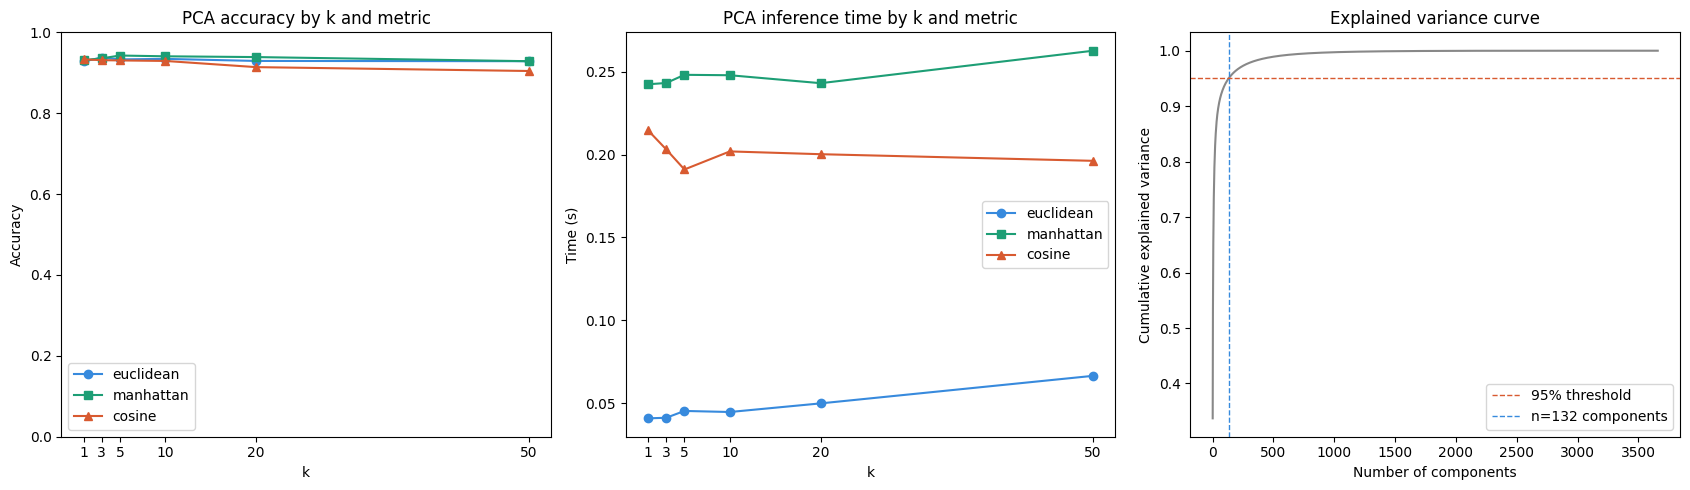

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = {"euclidean": "#378ADD", "manhattan": "#1D9E75", "cosine": "#D85A30"}
markers = {"euclidean": "o", "manhattan": "s", "cosine": "^"}

# 1. PCA accuracy across k and metrics
ax = axes[0]
for metric in metrics:
    ax.plot(K, results[metric]["acc_pca"], marker=markers[metric],
            label=metric, color=colors[metric])
ax.set_xlabel("k"); ax.set_ylabel("Accuracy")
ax.set_title("PCA accuracy by k and metric")
ax.set_xticks(K); ax.legend(); ax.set_ylim(0, 1)

# 2. PCA inference time across k and metrics
ax = axes[1]
for metric in metrics:
    ax.plot(K, results[metric]["t_pca"], marker=markers[metric],
            label=metric, color=colors[metric])
ax.set_xlabel("k"); ax.set_ylabel("Time (s)")
ax.set_title("PCA inference time by k and metric")
ax.set_xticks(K); ax.legend()

# 3. Explained variance curve
ax = axes[2]
ax.plot(np.arange(1, len(cumvar)+1), cumvar, color="#888", linewidth=1.5)
ax.axhline(0.95, color="#D85A30", linewidth=1, linestyle="--", label="95% threshold")
ax.axvline(n_95, color="#378ADD", linewidth=1, linestyle="--", label=f"n={n_95} components")
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative explained variance")
ax.set_title("Explained variance curve"); ax.legend()

plt.tight_layout()
plt.savefig("knn_pca.png", dpi=150, bbox_inches="tight")
plt.show()